In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
from pathlib import Path

# 机器学习核心库
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# 导入你提供的特征工程模块
from process_data import process_data, read_fasta

# 全局配置
warnings.filterwarnings('ignore')
plt.rcParams["font.sans-serif"] = ["SimHei"] # 解决中文显示问题
plt.rcParams["axes.unicode_minus"] = False

# 定义基础路径
BASE_PATH = Path('D:/Python/dachuang2026')

In [2]:
def plot_visualizations(y_true, y_pred, y_prob, feature_names, model, save_dir):
    """
    使用 seaborn (sns) 进行高级可视化
    """
    # 1. 混淆矩阵热力图
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['无毒(0)', '有毒(1)'],
                yticklabels=['无毒(0)', '有毒(1)'])
    plt.title('整合测试集 - 预测混淆矩阵')
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.savefig(save_dir / 'confusion_matrix.png', dpi=300)
    plt.show()

    # 2. 特征重要性条形图
    importances = model.feature_importances_
    feat_imp = pd.DataFrame({'特征': feature_names, '重要性': importances})
    feat_imp = feat_imp.sort_values(by='重要性', ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='重要性', y='特征', data=feat_imp, palette='viridis')
    plt.title('Top 20 核心预测特征 (XGBoost)')
    plt.tight_layout()
    plt.savefig(save_dir / 'feature_importance.png', dpi=300)
    plt.show()

    # 3. 预测概率分布图 (展示模型分类信心)
    plt.figure(figsize=(10, 6))
    sns.histplot(x=y_prob, hue=y_true, element="step", common_norm=False, palette='muted')
    plt.title('有毒/无毒预测概率分布 (Score Distribution)')
    plt.xlabel('预测为有毒的概率')
    plt.ylabel('样本数量')
    plt.savefig(save_dir / 'probability_distribution.png', dpi=300)
    plt.show()

In [3]:
def train_optimized_model(X_train, y_train):
    """
    使用带交叉验证的 XGBoost 模型
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # 计算类别权重（处理样本不平衡）
    ratio = (y_train == 0).sum() / (y_train == 1).sum()

    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8, 1.0],
        'scale_pos_weight': [ratio] # 自动平衡正负样本影响力
    }

    grid_search = GridSearchCV(
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        param_grid,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1',
        n_jobs=-1
    )

    print("🔍 正在搜索最佳超参数...")
    grid_search.fit(X_train_scaled, y_train)
    print(f"✅ 最佳参数: {grid_search.best_params_}")

    return grid_search.best_estimator_, scaler

In [4]:
def main():
    # 1. 结果保存目录
    results_dir = BASE_PATH / 'results_final'
    results_dir.mkdir(exist_ok=True)

    # 2. 加载并处理训练集
    print("Step 1: 处理训练数据...")
    train_file = BASE_PATH / 'data/train_data.fasta'
    train_raw = read_fasta(train_file)
    processed_train, train_config = process_data(train_raw)

    X_train = processed_train.drop(['Sequence', 'toxicity'], axis=1)
    y_train = processed_train['toxicity'].astype(int)

    # 3. 训练优化模型
    print("Step 2: 训练模型中...")
    model, scaler = train_optimized_model(X_train, y_train)

    # 4. 整合两个测试文件
    print("\nStep 3: 整合测试集 [test1.fasta + test2.fasta]...")
    test_files = [BASE_PATH / 'data/test1.fasta', BASE_PATH / 'data/test2.fasta']
    test_data_list = [read_fasta(f) for f in test_files if f.exists()]

    # 内存中合并
    combined_test_raw = pd.concat(test_data_list, ignore_index=True)

    # 使用训练集的 config 进行特征提取（确保二肽特征列完全一致）
    processed_test, _ = process_data(combined_test_raw, feature_config=train_config)

    X_test = processed_test.drop(['Sequence', 'toxicity'], axis=1)
    y_test = processed_test['toxicity'].astype(int)

    # 5. 特征对齐与标准化
    # 确保测试集拥有与训练集完全相同的列顺序
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    X_test_scaled = scaler.transform(X_test)

    # 6. 预测与评估
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # 输出性能指标
    print("\n" + "="*40)
    print(f"整合测试集样本总数: {len(y_test)}")
    print(f"准确率 (Accuracy):  {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 分数 (F1-score):  {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC 分数:       {roc_auc_score(y_test, y_prob):.4f}")
    print("="*40)
    print("\n详细分类报告:")
    print(classification_report(y_test, y_pred, target_names=['无毒(0)', '有毒(1)']))

    # 7. 调用 sns 进行可视化绘图
    print("\nStep 4: 生成可视化图表...")
    plot_visualizations(y_test, y_pred, y_prob, X_train.columns, model, results_dir)

    # # 8. 保存模型、标准化器及配置
    # joblib.dump(model, results_dir / 'xgboost_peptide_model.joblib')
    # joblib.dump(scaler, results_dir / 'scaler.pkl')
    # with open(results_dir / 'feature_config.json', 'w') as f:
    #     json.dump(train_config, f)
    #
    # print(f"\n📂 所有模型组件及图表已保存至: {results_dir}")

Step 1: 处理训练数据...
处理完成！样本数: 6387
特征维度: 128
Step 2: 训练模型中...
🔍 正在搜索最佳超参数...
✅ 最佳参数: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200, 'scale_pos_weight': np.float64(2.5132013201320134), 'subsample': 0.8}

Step 3: 整合测试集 [test1.fasta + test2.fasta]...
处理完成！样本数: 1708
特征维度: 128

整合测试集样本总数: 1708
准确率 (Accuracy):  0.9280
F1 分数 (F1-score):  0.8308
ROC-AUC 分数:       0.9651

详细分类报告:
              precision    recall  f1-score   support

       无毒(0)       0.95      0.96      0.95      1342
       有毒(1)       0.84      0.83      0.83       366

    accuracy                           0.93      1708
   macro avg       0.89      0.89      0.89      1708
weighted avg       0.93      0.93      0.93      1708


Step 4: 生成可视化图表...


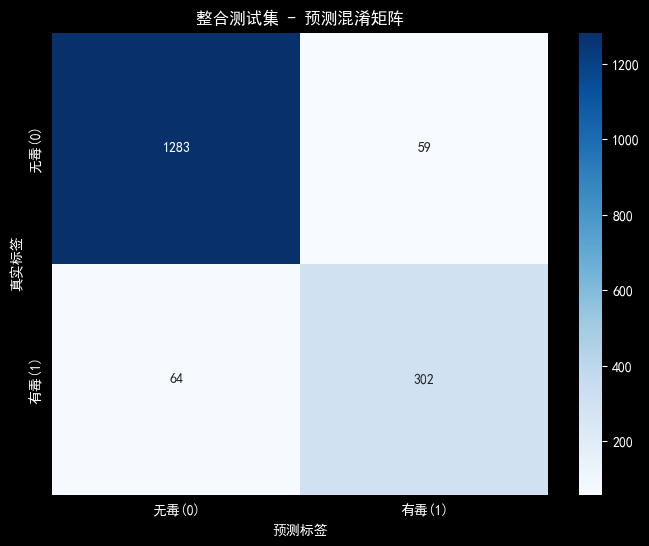

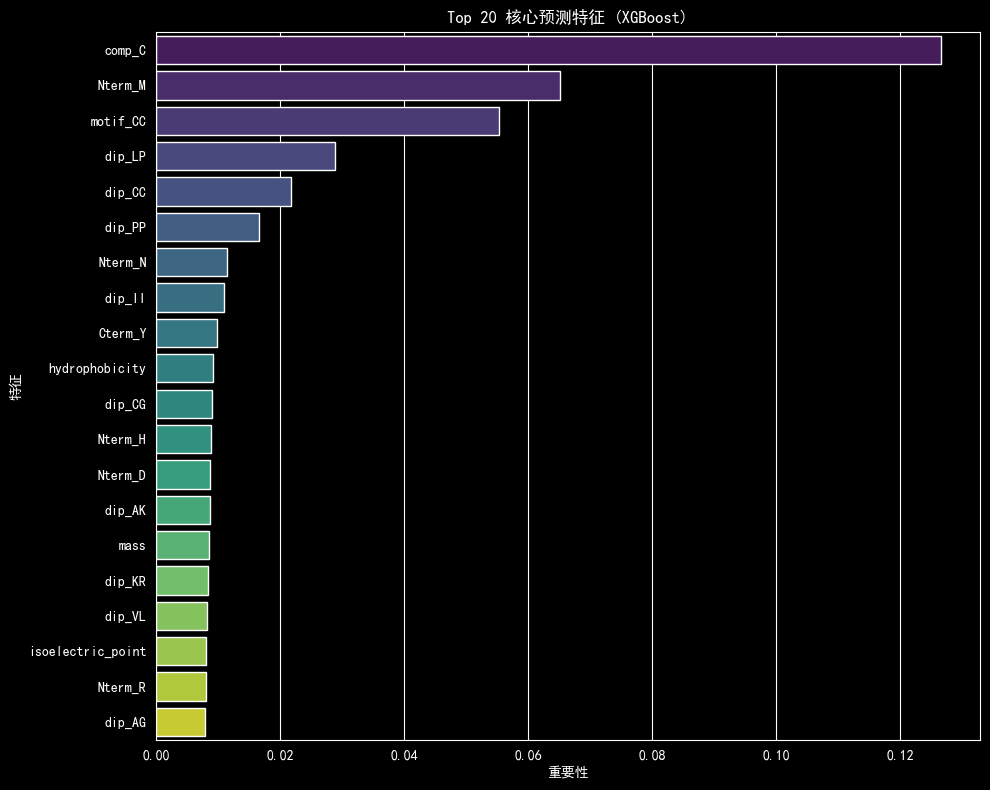

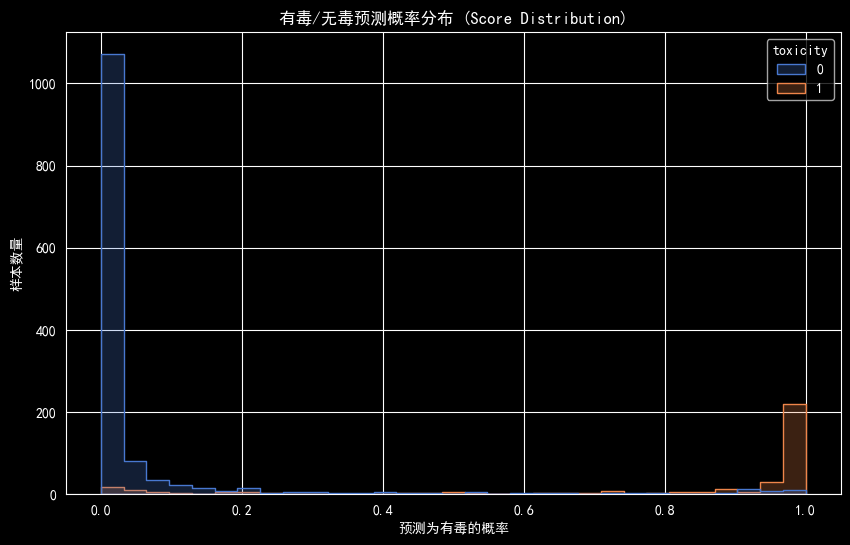

In [5]:
main()